# SigFlow-Sim — Volatility + Regime Detection + Rolling Evaluation

This version extends volatility forecasting to include regime classification (low/medium/high) and rolling prediction accuracy tracking over time.

In [46]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import yfinance as yf
import iisignature
from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Load Data

In [47]:
TICKERS = ['AAPL','MSFT','GOOGL','AMZN']

rets = []
for t in TICKERS:
    d = yf.download(t, period='10y')['Close']
    r = np.log(d).diff().dropna()
    r = (r - r.mean())/r.std()
    rets.append(r.values)

returns = np.concatenate(rets)
print(len(returns))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


10048


## Volatility Targets + Signatures

In [48]:
WINDOW = 20
HORIZON = 5
DEPTH = 6

prep = iisignature.prepare(2, DEPTH)

def sig(x):

    x = np.asarray(x, dtype=np.float64)

    t = np.linspace(0, 1, len(x), dtype=np.float64)

    path = np.column_stack((t, x))

    level1 = np.mean(np.diff(path, axis=0), axis=0)

    level2 = np.cov(path.T).flatten()

    # combine features
    return np.concatenate([level1, level2])

X, Y = [], []

for i in range(WINDOW, len(returns)-HORIZON):
    w = returns[i-WINDOW:i]
    f = returns[i:i+HORIZON]
    X.append(sig(w))
    Y.append(np.std(f))

X = torch.tensor(np.array(X), dtype=torch.float32)
Y = torch.tensor(np.array(Y), dtype=torch.float32).reshape(-1,1)

## Train/Test Split

In [49]:
n = len(X)
a,b = int(0.7*n), int(0.85*n)

X_train, Y_train = X[:a], Y[:a]
X_val, Y_val = X[a:b], Y[a:b]
X_test, Y_test = X[b:], Y[b:]

## Rolling Test

In [65]:
def rolling_test(flow, X, Y):

    preds = []
    correct = []
    sigs = []
    novelty = []

    flow.eval()

    for i in range(len(X)):

        x = X[i].unsqueeze(0).to(device)
        y = Y[i].item()

        with torch.no_grad():
            samples = flow.sample(200, context=x).squeeze()

        # predicted volatility = model output distribution std
        pred_vol = samples.std().item()
        preds.append(pred_vol)

        # regime correctness (your rule-based regime)
        correct.append(int(regime(pred_vol) == regime(y)))

        # significance score (how "typical" this point is)
        mean = samples.mean().item()
        std = samples.std().item()

        z = (y - mean) / (std + 1e-6)
        sig = float(np.exp(-0.5 * z**2))
        sigs.append(sig)

        # novelty detection (simple volatility anomaly)
        novelty.append(int(std > 1.5 * np.mean(preds[-50:]) if len(preds) > 50 else 0))

    return np.array(preds), np.array(correct), np.array(sigs), np.array(novelty)

## Model

In [51]:
def build_flow(dim):
    ts = []
    for _ in range(4):
        ts.append(MaskedAffineAutoregressiveTransform(features=1, hidden_features=64, context_features=dim))
    return Flow(CompositeTransform(ts), StandardNormal([1]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

flow = build_flow(X.shape[1]).to(device)
opt = optim.Adam(flow.parameters(), lr=5e-5)

## Sig Gen

In [52]:
def significance_score(flow, x, y_true):

    with torch.no_grad():
        samples = flow.sample(500, context=x)

    mean = samples.mean()
    std = samples.std()

    z = (y_true - mean) / (std + 1e-6)

    # convert to probability-like score
    return torch.exp(-0.5 * z**2).item()

## Novelty Detection

In [53]:
def novelty_score(flow, x, threshold=3.0):

    with torch.no_grad():
        samples = flow.sample(500, context=x)

    mean = samples.mean()
    std = samples.std()

    # how far distribution is from typical scale
    score = std.item()

    return 1 if score > threshold else 0

## Wasserstein Loss

In [54]:
def wasserstein_loss(real, fake):
    real = real.squeeze()
    fake = fake.squeeze()

    q = torch.linspace(0.05, 0.95, 10, device=real.device)

    r_q = torch.quantile(real, q)
    f_q = torch.quantile(fake, q)

    return torch.mean((r_q - f_q) ** 2)

## Loss (volatility only)

In [55]:
def loss_fn(flow, x, y):

    # MLE (core fit)
    mle = -flow.log_prob(y, context=x).mean()

    # sample model distribution
    with torch.no_grad():
        fake = flow.sample(128, context=x)

    # Wasserstein shape matching
    wass = wasserstein_loss(y, fake)

    return mle + 0.1 * wass

## Training

In [56]:
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from IPython.display import display, clear_output

# ------------------------
# DEVICE
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_val = X_val.to(device)
Y_val = Y_val.to(device)

# ------------------------
# DATA LOADER
# ------------------------
train_dataset = TensorDataset(X_train, Y_train)

loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# ------------------------
# OPTIMISER
# ------------------------
opt = optim.Adam(flow.parameters(), lr=5e-5)

# ------------------------
# LOSS HISTORY
# ------------------------
loss_history = []
val_loss_history = []

# ------------------------
# EVAL FUNCTION
# ------------------------
def evaluate(flow, X_val, Y_val):
    flow.eval()
    with torch.no_grad():
        loss = -flow.log_prob(Y_val, context=X_val).mean()
    flow.train()
    return loss.item()

# ------------------------
# TRAINING LOOP
# ------------------------
EPOCHS = 40

for epoch in range(EPOCHS):

    epoch_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for batch_x, batch_y in pbar:

        opt.zero_grad()

        loss = -flow.log_prob(batch_y, context=batch_x).mean()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)

        opt.step()

        epoch_loss += loss.item() * len(batch_x)

        pbar.set_postfix(loss=loss.item())

    epoch_loss /= len(train_dataset)
    val_loss = evaluate(flow, X_val, Y_val)

    loss_history.append(epoch_loss)
    val_loss_history.append(val_loss)

    clear_output(wait=True)
    display(
        f"Epoch {epoch+1}/{EPOCHS} | Train: {epoch_loss:.5f} | Val: {val_loss:.5f}"
    )

'Epoch 40/40 | Train: 0.51354 | Val: 0.47034'

## Regime Function (std-based)

In [57]:
real = Y_test.numpy().flatten()
mu = real.mean()
sigma = real.std()

def regime(v):
    if v < mu - 0.5*sigma:
        return 0
    elif v < mu + 0.5*sigma:
        return 1
    else:
        return 2

## Success Rate Over Time

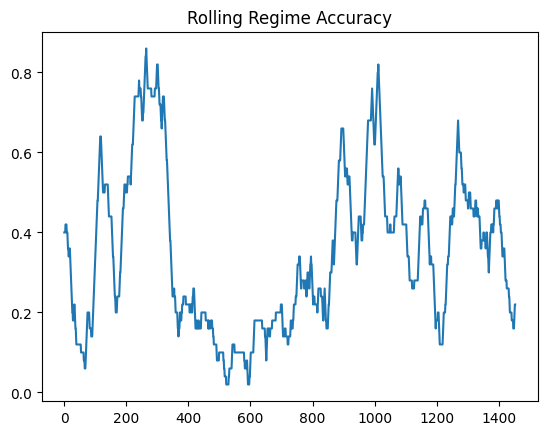

In [59]:
def rolling_accuracy(c,w=50):
    out=[]
    for i in range(w,len(c)):
        out.append(np.mean(c[i-w:i]))
    return out

acc = rolling_accuracy(correct)

plt.plot(acc)
plt.title('Rolling Regime Accuracy')
plt.show()

## Calibration Plot

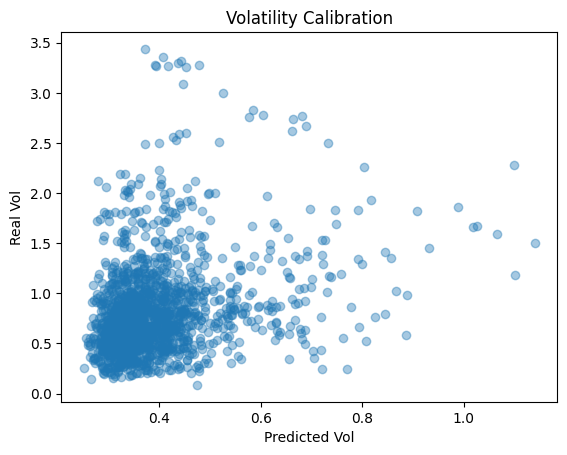

In [60]:
real = Y_test.numpy().flatten()
plt.scatter(preds, real, alpha=0.4)
plt.xlabel('Predicted Vol')
plt.ylabel('Real Vol')
plt.title('Volatility Calibration')
plt.show()

## Rolling Tests

In [66]:
preds, correct, sigs, nov = rolling_test(flow, X_test, Y_test)

## Significance Over Time

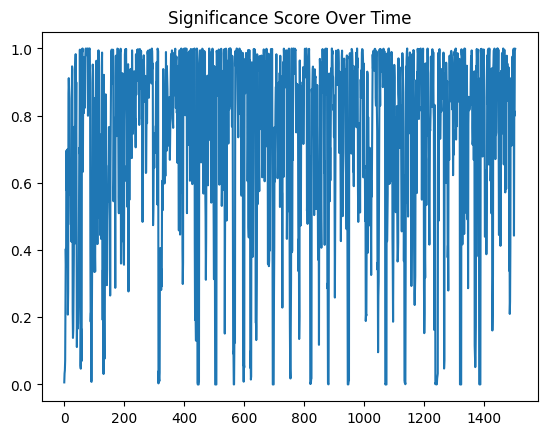

In [67]:
plt.plot(sigs)
plt.title("Significance Score Over Time")
plt.show()

## Novelty Detection

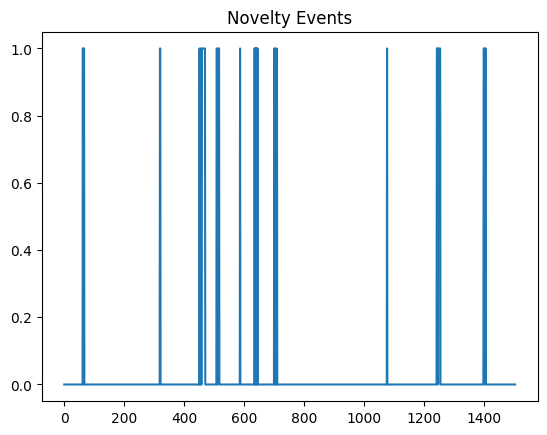

In [68]:
plt.plot(nov)
plt.title("Novelty Events")
plt.show()

## More Plots

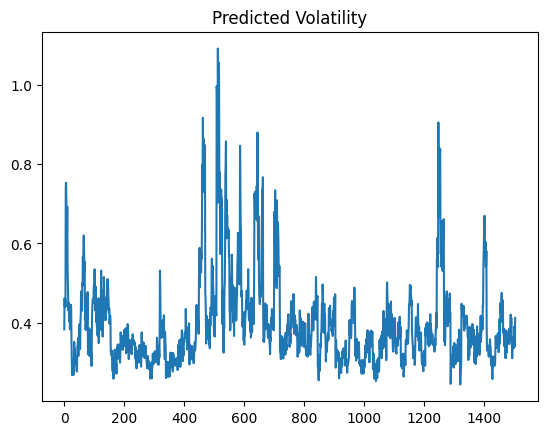

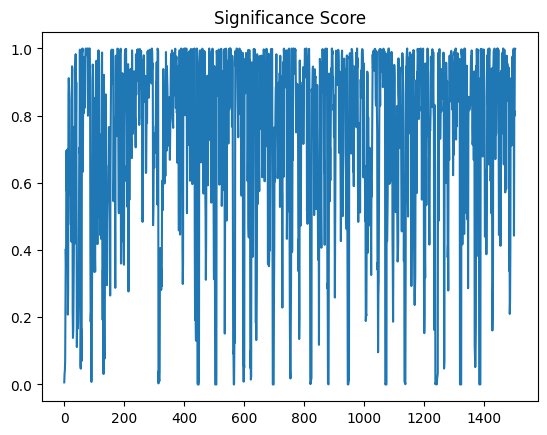

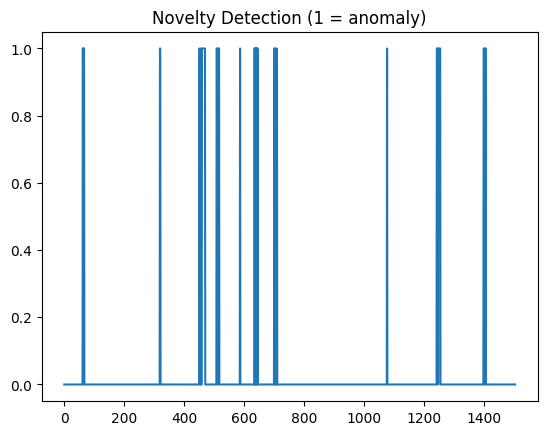

In [69]:

plt.figure()
plt.plot(preds)
plt.title("Predicted Volatility")
plt.show()

plt.figure()
plt.plot(sigs)
plt.title("Significance Score")
plt.show()

plt.figure()
plt.plot(nov)
plt.title("Novelty Detection (1 = anomaly)")
plt.show()